# 07 — Rotation, storage, and shader code

The math is settled. This notebook is engineering: how coefficients behave under
rotation, how they get packed into memory, what the shader actually looks like, and
which conventions will silently break your lighting.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt

import shlib as sh
import shplot as sp

sp.use_style()
np.set_printoptions(precision=4, suppress=True, linewidth=110)

## 1. Rotation preserves bands

The property that makes SH usable in a real engine:

> Rotating a function mixes coefficients **within** each band, never across bands.

So the $(\ell+1)^2 \times (\ell+1)^2$ rotation matrix is **block diagonal**: a
$1\times1$ block for band 0, $3\times3$ for band 1, $5\times5$ for band 2.

- **Band 0 is invariant.** The average light doesn't change when you turn your head.
- **Band 1 rotates exactly like a direction vector** — it *is* a vector, in the
  $(y, z, x)$ ordering.
- **Band 2** needs a genuine $5\times5$.

band 0 block:            1.000000   (always exactly 1)
largest off-band entry:  0.00e+00   (bands never mix)
orthogonality |M M^T-I|: 5.94e-15


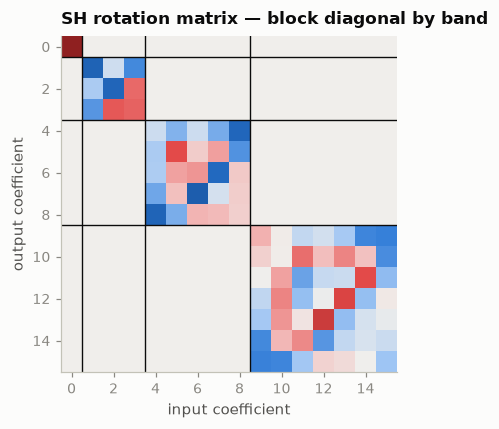

In [2]:
def rand_rotation(rng):
    A = rng.normal(size=(3,3))
    Q, R = np.linalg.qr(A)
    Q *= np.sign(np.diag(R))
    if np.linalg.det(Q) < 0: Q[:, 0] *= -1
    return Q

rng = np.random.default_rng(4)
R = rand_rotation(rng)
M = sh.rotation_matrix_sh(3, R)

fig, ax = plt.subplots(figsize=(4.2, 4.0))
ax.imshow(M, cmap=sp.CM_DIVERGING, **sp.signed_norm(M))
for l in range(1, 4):
    ax.axhline(l*l - 0.5, color=sp.INK, lw=0.9)
    ax.axvline(l*l - 0.5, color=sp.INK, lw=0.9)
ax.set_title("SH rotation matrix — block diagonal by band")
ax.set_xlabel("input coefficient"); ax.set_ylabel("output coefficient")
ax.grid(False)
fig.tight_layout()

print(f"band 0 block:            {M[0,0]:.6f}   (always exactly 1)")
off = M.copy()
for l in range(4):
    off[l*l:(l+1)**2, l*l:(l+1)**2] = 0
print(f"largest off-band entry:  {np.abs(off).max():.2e}   (bands never mix)")
print(f"orthogonality |M M^T-I|: {np.abs(M@M.T - np.eye(16)).max():.2e}")

In [3]:
# Band 1 IS the rotation matrix, just with axes permuted to (y, z, x).
B1 = M[1:4, 1:4]
perm = [1, 2, 0]                       # SH band-1 order (y,z,x) -> (x,y,z)
print("band-1 block of the SH rotation:\n", np.round(B1, 5))
print("\nthe 3x3 rotation, reordered to (y,z,x):\n", np.round(R[np.ix_(perm, perm)], 5))
print(f"\nmatch: {np.allclose(B1, R[np.ix_(perm, perm)], atol=1e-8)}")

band-1 block of the SH rotation:
 [[-0.7959 -0.1356 -0.59  ]
 [-0.2807 -0.7809  0.5581]
 [-0.5364  0.6098  0.5834]]

the 3x3 rotation, reordered to (y,z,x):
 [[-0.7959 -0.1356 -0.59  ]
 [-0.2807 -0.7809  0.5581]
 [-0.5364  0.6098  0.5834]]

match: True


That is a genuinely useful fact: **to rotate an L1 probe you just rotate a vector.**
No matrices, no tables. For L1 probes (common on mobile and for vegetation) rotation
is nearly free.

(<Figure size 1650x264 with 4 Axes>,
 array([[<Axes: title={'left': 'rotated 0° about Z'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>,
         <Axes: title={'left': 'rotated 45° about Z'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>,
         <Axes: title={'left': 'rotated 90° about Z'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>,
         <Axes: title={'left': 'rotated 135° about Z'}, xlabel='azimuth $\\phi$ (deg)', ylabel='polar $\\theta$'>]],
       dtype=object))

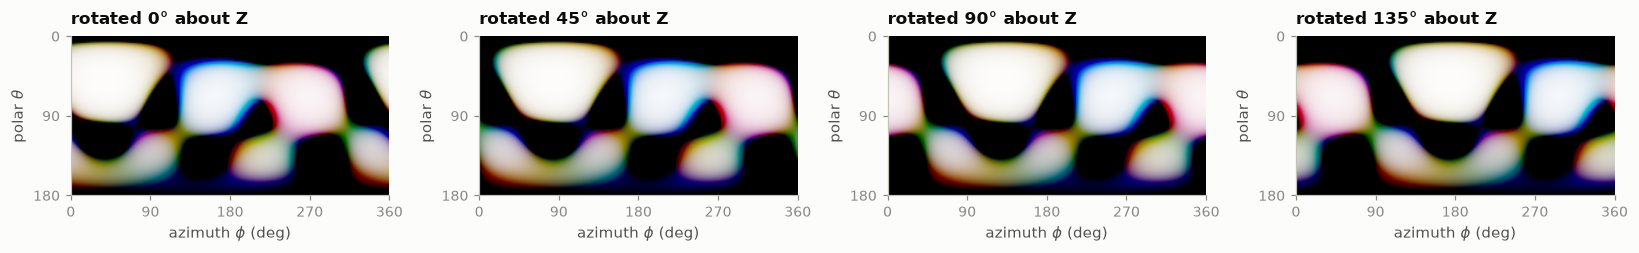

In [4]:
# Rotation in action: same lighting, rotated environment.
import shscene as ss
c = sh.project_env(ss.sky_studio, 4, n_samples=300_000)

angles = [0, 45, 90, 135]
imgs, titles = [], []
for a in angles:
    t = np.radians(a)
    Rz = np.array([[np.cos(t), -np.sin(t), 0],[np.sin(t), np.cos(t), 0],[0,0,1]])
    cr = np.stack([sh.rotate_sh(c[:, ch], Rz) for ch in range(3)], axis=-1)
    im = sh.sh_to_equirect(cr, 240, 120)
    imgs.append(ss.srgb_encode(ss.tonemap(im, 1.0, "aces")))
    titles.append(f"rotated {a}° about Z")
sp.show_images(imgs, titles, cols=4, figsize=(15.0, 2.4))

In [5]:
# Rotating the coefficients == rotating the function. Verify, don't assume.
d = sh.fibonacci_sphere(4000)
R = rand_rotation(np.random.default_rng(9))
c1 = sh.project_env(ss.sky_studio, 4, n_samples=200_000)[:, 0]

lhs = sh.reconstruct(sh.rotate_sh(c1, R), d)     # rotate coefficients
rhs = sh.reconstruct(c1, d @ R)                  # rotate the query direction
print(f"max difference: {np.abs(lhs - rhs).max():.2e}")

# Rotation and the cosine convolution commute -- irradiance is rotation-equivariant.
a = sh.convolve_cosine(sh.rotate_sh(c1, R))
b = sh.rotate_sh(sh.convolve_cosine(c1), R)
print(f"rotate-then-convolve vs convolve-then-rotate: {np.abs(a-b).max():.2e}")

max difference: 1.60e-14
rotate-then-convolve vs convolve-then-rotate: 2.22e-16


### The zonal shortcut

If a lobe is rotationally symmetric (like the cosine lobe, or a soft area light),
you don't need rotation matrices at all. Store $\ell+1$ zonal coefficients and aim
it with one basis evaluation:

$$c_{\ell m} = \sqrt{\frac{4\pi}{2\ell+1}}\;z_\ell\;y_\ell^m(\mathbf{a})$$

This is how engines add analytic light sources into an SH probe cheaply.

In [6]:
axis = np.array([0.4, -0.6, 0.7]); axis /= np.linalg.norm(axis)
zh = sh.cosine_lobe_zh(4) / np.array([np.sqrt(4*np.pi/(2*l+1)) for l in range(5)])

fast = sh.rotate_zh_to_axis(zh, axis)
slow = sh.project_env(lambda d: np.maximum(0.0, d @ axis), 4, n_samples=400_000)
print(f"ZH shortcut vs full projection:  max difference {np.abs(fast-slow).max():.2e}")
print(f"cost:  {len(zh)} stored numbers + 1 basis eval,  vs {len(slow)} numbers + a 25x25 matrix")

ZH shortcut vs full projection:  max difference 1.22e-07
cost:  5 stored numbers + 1 basis eval,  vs 25 numbers + a 25x25 matrix


## 2. Storage layouts

### What to store

Store **radiance** coefficients or **irradiance** coefficients (radiance already
scaled by $\hat{A}_\ell$)? Both ship. Pre-convolving saves 9 multiplies per pixel
but locks the probe to diffuse use. Most engines pre-convolve.

### Budget

In [7]:
rows = [("L0 (ambient)", 1), ("L1", 4), ("L2", 9), ("L3", 16), ("L4", 25)]
print(f"{'layout':<16}{'coef':>6}{'RGB floats':>12}{'fp32 B':>9}{'fp16 B':>9}"
      f"{'probes in 1 MB (fp16)':>24}")
print("-" * 78)
for name, n in rows:
    b16 = n*3*2
    print(f"{name:<16}{n:>6}{n*3:>12}{n*3*4:>9}{b16:>9}{1024*1024//b16:>24,}")

layout            coef  RGB floats   fp32 B   fp16 B   probes in 1 MB (fp16)
------------------------------------------------------------------------------
L0 (ambient)         1           3       12        6                 174,762
L1                   4          12       48       24                  43,690
L2                   9          27      108       54                  19,418
L3                  16          48      192       96                  10,922
L4                  25          75      300      150                   6,990


An L2 probe is 54 bytes at fp16. You can hold ~19,000 of them in a megabyte —
which is why dense probe volumes became practical.

### The classic 7-vector packing

The standard trick: fold the $\hat{A}_\ell$ scales and basis constants into the
stored data so the shader does pure `dot` products with no magic numbers. You get
**7 float4s** for L2 RGB:

```
sh_r = (L11*k, L1-1*k, L10*k, L00*k' - L20*k'')   // linear + constant, red
sh_g = ...                                         // green
sh_b = ...                                         // blue
sh_br = (L2-2, L2-1, L21, L22)  scaled, red        // quadratic, red
sh_bg = ...                                        // green
sh_bb = ...                                        // blue
sh_c  = (L20_r, L20_g, L20_b, 1)                   // the z^2 term
```

Three float4s for the constant+linear part (which alone gives you an L1 probe), plus
four more for the quadratic. Convenient: **drop the last four and you have a valid
L1 probe** with no repacking.

(That is 28 floats for 27 coefficients — `sh_c.w` is unused padding, set to 1.0.
Vector registers are four-wide whether you fill them or not.)

In [8]:
# Pack (9,3) radiance coefficients into the 7-float4 shader layout.
# The constants fold in A_l and the basis normalisations, so the shader
# does dot products only -- no magic numbers at runtime.
def pack_sh_l2(c):
    c = np.asarray(c, dtype=float)
    A = sh.cosine_lobe_zh(2)
    k = [0.282095, 0.488603, 1.092548, 0.315392, 0.546274]

    out = {}
    for i, ch in enumerate("rgb"):
        out[f"sh_a{ch}"] = np.array([
            A[1]*k[1]*c[3, i],    # x  <- y(1,1)
            A[1]*k[1]*c[1, i],    # y  <- y(1,-1)
            A[1]*k[1]*c[2, i],    # z  <- y(1,0)
            # constant: band 0, plus the -1 inside y(2,0)'s (3z^2 - 1)
            A[0]*k[0]*c[0, i] - A[2]*k[3]*c[6, i],
        ])
        out[f"sh_b{ch}"] = np.array([
            A[2]*k[2]*c[4, i], A[2]*k[2]*c[5, i],
            3.0*A[2]*k[3]*c[6, i], A[2]*k[2]*c[7, i],
        ])
    out["sh_c"] = np.array([A[2]*k[4]*c[8, 0], A[2]*k[4]*c[8, 1],
                            A[2]*k[4]*c[8, 2], 1.0])
    return out

c_rgb = sh.project_env(ss.sky_studio, 2, n_samples=300_000)
packed = pack_sh_l2(c_rgb)
for name, v in packed.items():
    print(f"{name:>6}  [{v[0]:+9.5f} {v[1]:+9.5f} {v[2]:+9.5f} {v[3]:+9.5f}]")
print(f"\ntotal: {len(packed)} float4 = {len(packed)*4} floats = {len(packed)*4*2} bytes at fp16")

 sh_ar  [ +0.48659  +0.02445  +1.48612  +1.79353]


 sh_br  [ +0.84242  +0.45893  -0.25980  +0.71952]
 sh_ag  [ +0.24551  +0.41110  +1.24719  +1.46105]
 sh_bg  [ +0.57733  +0.60538  -0.16243  +0.49263]
 sh_ab  [ -0.28849  +0.24240  +1.23037  +1.58515]
 sh_bb  [ +0.30013  +0.44220  -0.28967  +0.05804]
  sh_c  [ -0.14357  +0.07908  +0.13732  +1.00000]

total: 7 float4 = 28 floats = 56 bytes at fp16


## 3. The shader

Two versions. Start with **L1**, which is what you want on mobile or for
low-importance objects — 4 coefficients per channel, and the rotation shortcut above
makes it nearly free.

```hlsl
// ---- L1: constant + linear. 12 floats per probe. ----
float3 SHEvalL1(float4 shAr, float4 shAg, float4 shAb, float3 n)
{
    float4 v = float4(n, 1.0);
    return float3(dot(shAr, v), dot(shAg, v), dot(shAb, v));
}
```

Three dot products. That is the whole thing.

```hlsl
// ---- L2: adds the quadratic band. 27 floats per probe. ----
float3 SHEvalL2(float4 shAr, float4 shAg, float4 shAb,
                float4 shBr, float4 shBg, float4 shBb,
                float4 shC,  float3 n)
{
    // linear + constant
    float4 v  = float4(n, 1.0);
    float3 x1 = float3(dot(shAr, v), dot(shAg, v), dot(shAb, v));

    // quadratic: (xy, yz, zz, xz)
    float4 b  = n.xyzz * n.yzzx;
    float3 x2 = float3(dot(shBr, b), dot(shBg, b), dot(shBb, b));

    // the (x^2 - y^2) term
    float  c  = n.x * n.x - n.y * n.y;
    float3 x3 = shC.rgb * c;

    return x1 + x2 + x3;
}

// Usage in a pixel shader:
float3 N         = normalize(worldNormal);
float3 irradiance = SHEvalL2(shAr, shAg, shAb, shBr, shBg, shBb, shC, N);
float3 diffuse    = albedo * irradiance;   // A_l already folded in at bake time
```

GLSL is a near-transliteration:

```glsl
vec3 SHEvalL2(vec4 shAr, vec4 shAg, vec4 shAb,
              vec4 shBr, vec4 shBg, vec4 shBb,
              vec4 shC,  vec3 n)
{
    vec4 v  = vec4(n, 1.0);
    vec3 x1 = vec3(dot(shAr, v), dot(shAg, v), dot(shAb, v));

    vec4 b  = n.xyzz * n.yzzx;
    vec3 x2 = vec3(dot(shBr, b), dot(shBg, b), dot(shBb, b));

    vec3 x3 = shC.rgb * (n.x * n.x - n.y * n.y);
    return x1 + x2 + x3;
}
```

Roughly **20 ALU** for full directional diffuse lighting, no texture fetches, no
branches. Compare against a cubemap fetch plus filtering.

In [9]:
# Emulate the shader exactly and check it against the reference implementation.
def shader_eval_l2(packed, n):
    n = np.atleast_2d(n)
    v = np.concatenate([n, np.ones((len(n),1))], axis=1)
    x1 = np.stack([v @ packed[f"sh_a{ch}"] for ch in "rgb"], axis=-1)
    b = np.stack([n[:,0]*n[:,1], n[:,1]*n[:,2], n[:,2]*n[:,2], n[:,2]*n[:,0]], axis=1)
    x2 = np.stack([b @ packed[f"sh_b{ch}"] for ch in "rgb"], axis=-1)
    x3 = packed["sh_c"][:3] * (n[:,0]**2 - n[:,1]**2)[:, None]
    return x1 + x2 + x3

nn = sh.fibonacci_sphere(400)
ref = sh.irradiance_from_sh(c_rgb, nn)
got = shader_eval_l2(packed, nn)
print(f"packed shader form vs reference:  max difference {np.abs(got - ref).max():.2e}")
print(f"                                  relative      {sh.relative_error(got, ref)*100:.4f}%")

packed shader form vs reference:  max difference 2.57e-06
                                  relative      0.0001%


## 4. Conventions that will break your lighting

This is the section to re-read when something looks subtly wrong.

**Up axis.** This series is Z-up. Unity, Unreal and Godot are Y-up. If you take the
polynomial table from notebook 04 verbatim into a Y-up engine, `y` and `z` swap
roles and your lighting is rotated 90°. Either swizzle the normal before evaluating
or rewrite the table.

**Handedness.** Going between left- and right-handed spaces flips one axis, which
negates the band-1 coefficient for that axis and the band-2 cross terms involving
it. The result looks *plausible* — smooth, correctly-coloured, mirrored — which is
what makes it so easy to ship by accident. The packing function above has **no**
sign flips because it stays in one convention throughout; if you port it into an
engine whose handedness differs, that is where the flips belong.

**Condon–Shortley phase.** Covered in notebook 03. Odd-$m$ sign flips. If you mix a
`scipy`-derived table with a graphics-derived one you will hit this.

**Radiance vs irradiance.** Is $\hat{A}_\ell$ already folded in? Applying it twice
gives lighting that is too dark and too smooth; forgetting it gives lighting far too
bright and too contrasty.

The reliable test for all four: **bake a probe from a single bright light in a known
direction and check the lit sphere is brightest facing that direction.**

In [10]:
# The convention smoke test. Run this whenever you port SH code.
for name, axis in [("+X", [1,0,0]), ("+Y", [0,1,0]), ("+Z", [0,0,1])]:
    a = np.array(axis, dtype=float)
    c1 = sh.project_env(lambda d: (np.maximum(0, d @ a) > 0.99).astype(float)*50, 2,
                        n_samples=400_000)
    test = sh.fibonacci_sphere(4000)
    E = sh.irradiance_from_sh(c1, test)
    best = test[np.argmax(E)]
    ok = np.dot(best, a) > 0.95
    print(f"light at {name}: brightest normal = [{best[0]:+.2f} {best[1]:+.2f} {best[2]:+.2f}]"
          f"   {'OK' if ok else 'MISMATCH'}")

light at +X: brightest normal = [+1.00 -0.01 -0.01]   OK

light at +Y: brightest normal = [+0.01 +1.00 +0.01]   OK


light at +Z: brightest normal = [+0.01 +0.02 +1.00]   OK


## 5. Probe placement and interpolation

Coefficients are linear, so **interpolating probes is valid**: a weighted blend of
coefficient sets equals the coefficient set of the blended lighting. You can lerp
them like any other vertex attribute.

| scheme | how it works | trade-off |
|---|---|---|
| **Single probe per object** | nearest probe, applied whole | cheapest; pops as objects move |
| **Regular 3D grid** | trilinear blend of 8 neighbours | simple, GPU-friendly; wastes probes in empty space |
| **Tetrahedral** | Delaunay over hand/auto-placed probes | adapts to level shape; needs a CPU lookup |
| **Cascaded / adaptive volumes** | denser near geometry | best quality-per-probe; most machinery |

The universal failure mode is **light leaking**: a probe inside a wall, or one that
straddles indoor and outdoor, gets blended into surfaces that should not see that
light. Mitigations — visibility/occlusion terms per probe, depth-aware weighting,
manual placement — all amount to admitting that a probe stores *no* geometric
information, only a spherical average.

Notebook 08 builds a grid and shows leaking happening.

---

**Next:** [08 — Lighting a small scene](08_lighting_a_scene.ipynb)